**Import Liberaries**

In [79]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


**Load Dataset**

In [82]:
df = pd.read_csv("Sales_Data.csv")
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [83]:
FILE_PATH = "sales_data.csv"

if not os.path.exists(FILE_PATH):
    raise FileNotFoundError(
        f"File '{FILE_PATH}' was not found. "
        "Please place sales_data.csv in the same folder as this notebook."
    )

sales_df = pd.read_csv(FILE_PATH)

print("Dataset loaded successfully!")
print(f"Rows    : {sales_df.shape[0]}")
print(f"Columns : {sales_df.shape[1]}")

Dataset loaded successfully!
Rows    : 1000
Columns : 14


**Display Datset**

In [84]:
df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [86]:
df.describe()

,Product_ID,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1050.128000,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,29.573505,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,1001.000000,100.120000,1.000000,60.280000,167.120000,0.00000
25%,1024.000000,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,1051.000000,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,1075.000000,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,1100.000000,9989.040000,49.000000,4995.300000,5442.150000,0.30000


In [87]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

In [88]:
df.shape

(1000, 14)

In [89]:
df.columns.to_list()

['Product_ID',
 'Sale_Date',
 'Sales_Rep',
 'Region',
 'Sales_Amount',
 'Quantity_Sold',
 'Product_Category',
 'Unit_Cost',
 'Unit_Price',
 'Customer_Type',
 'Discount',
 'Payment_Method',
 'Sales_Channel',
 'Region_and_Sales_Rep']

**Check Missing Values**

In [90]:
missing_values = sales_df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing_Count": missing_values,
    "Missing_Percentage": (missing_values / len(sales_df)) * 100
})

display(missing_table)

,Missing_Count,Missing_Percentage
Product_ID,0,0.0
Sale_Date,0,0.0
Sales_Rep,0,0.0
Region,0,0.0
Sales_Amount,0,0.0
Quantity_Sold,0,0.0
Product_Category,0,0.0
Unit_Cost,0,0.0
Unit_Price,0,0.0
Customer_Type,0,0.0


**Data Cleaning**

In [91]:
sales_df["Sale_Date"] = pd.to_datetime(
    sales_df["Sale_Date"],
    errors="coerce"
)

print("Sale_Date converted to datetime.")
print("Invalid dates:", sales_df["Sale_Date"].isna().sum())

Sale_Date converted to datetime.
Invalid dates: 0


In [92]:
# Numerical columns
numeric_columns = [
    "Sales_Amount",
    "Quantity_Sold",
    "Unit_Cost",
    "Unit_Price",
    "Discount"
]

# Convert numerical columns safely
for column in numeric_columns:
    sales_df[column] = pd.to_numeric(
        sales_df[column],
        errors="coerce"
    )

display(sales_df[numeric_columns].describe())

,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,5019.265230,25.355000,2475.304550,2728.440120,0.15239
std,2846.790126,14.159006,1417.872546,1419.399839,0.08720
min,100.120000,1.000000,60.280000,167.120000,0.00000
25%,2550.297500,13.000000,1238.380000,1509.085000,0.08000
50%,5019.300000,25.000000,2467.235000,2696.400000,0.15000
75%,7507.445000,38.000000,3702.865000,3957.970000,0.23000
max,9989.040000,49.000000,4995.300000,5442.150000,0.30000


**Validate Data Using Loops & Conditions**

In [93]:
validation_errors = []

for column in numeric_columns:
    
    invalid_count = sales_df[column].isna().sum()
    
    if invalid_count > 0:
        validation_errors.append(
            f"{column}: {invalid_count} invalid values"
        )

# Check important business rules
if (sales_df["Sales_Amount"] < 0).any():
    validation_errors.append("Negative Sales_Amount found.")

if (sales_df["Quantity_Sold"] <= 0).any():
    validation_errors.append("Invalid Quantity_Sold found.")

if ((sales_df["Discount"] < 0) | (sales_df["Discount"] > 1)).any():
    validation_errors.append(
        "Discount values outside 0-1 range found."
    )

if len(validation_errors) == 0:
    print("✓ All validation checks passed.")
else:
    print("⚠ Validation issues:")
    for error in validation_errors:
        print("-", error)

✓ All validation checks passed.


**Create Useful Columns**

In [94]:
# Year
sales_df["Year"] = sales_df["Sale_Date"].dt.year

# Month
sales_df["Month"] = sales_df["Sale_Date"].dt.month

# Month name
sales_df["Month_Name"] = sales_df["Sale_Date"].dt.month_name()

# Quarter
sales_df["Quarter"] = sales_df["Sale_Date"].dt.quarter

# Year-Month
sales_df["Year_Month"] = sales_df["Sale_Date"].dt.to_period("M").astype(str)

# Total Cost
sales_df["Total_Cost"] = (
    sales_df["Unit_Cost"] * sales_df["Quantity_Sold"]
)

# Estimated Profit
sales_df["Profit"] = (
    sales_df["Sales_Amount"] - sales_df["Total_Cost"]
)

# Profit Margin
sales_df["Profit_Margin"] = np.where(
    sales_df["Sales_Amount"] != 0,
    (sales_df["Profit"] / sales_df["Sales_Amount"]) * 100,
    0
)

display(sales_df.head())

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Year,Month,Month_Name,Quarter,Year_Month,Total_Cost,Profit,Profit_Margin
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2023,2,February,1,2023-02,2749.50,2304.47,45.597224
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,2023,4,April,2,2023-04,64878.63,-60494.61,-1379.889006
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David,2023,9,September,3,2023-09,7846.80,-3215.57,-69.432311
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob,2023,8,August,3,2023-08,168871.17,-166703.23,-7689.476185
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,2023,3,March,1,2023-03,8285.81,-4535.61,-120.943150


**NumPy Integration**

In [95]:
sales_array = sales_df["Sales_Amount"].to_numpy()

total_sales = np.sum(sales_array)
average_sales = np.mean(sales_array)
maximum_sale = np.max(sales_array)
minimum_sale = np.min(sales_array)
sales_std = np.std(sales_array)

print(f"Total Sales       : ${total_sales:,.2f}")
print(f"Average Sale      : ${average_sales:,.2f}")
print(f"Maximum Sale      : ${maximum_sale:,.2f}")
print(f"Minimum Sale      : ${minimum_sale:,.2f}")
print(f"Sales Std. Dev.   : ${sales_std:,.2f}")

Total Sales       : $5,019,265.23
Average Sale      : $5,019.27
Maximum Sale      : $9,989.04
Minimum Sale      : $100.12
Sales Std. Dev.   : $2,845.37


In [96]:
quantity_array = sales_df["Quantity_Sold"].to_numpy()

print("Total Quantity Sold :", np.sum(quantity_array))
print("Average Quantity    :", round(np.mean(quantity_array), 2))
print("Maximum Quantity    :", np.max(quantity_array))
print("Minimum Quantity    :", np.min(quantity_array))

Total Quantity Sold : 25355
Average Quantity    : 25.36
Maximum Quantity    : 49
Minimum Quantity    : 1


**Object Oriented Programming(OOP)**

In [97]:
class SalesAnalyzer:
    
    def __init__(self, data):
        self.data = data.copy()
    
    def total_sales(self):
        return self.data["Sales_Amount"].sum()
    
    def average_sales(self):
        return self.data["Sales_Amount"].mean()
    
    def total_quantity(self):
        return self.data["Quantity_Sold"].sum()
    
    def most_popular_product(self):
        product_sales = (
            self.data
            .groupby("Product_ID")["Quantity_Sold"]
            .sum()
            .sort_values(ascending=False)
        )
        
        return product_sales.index[0], product_sales.iloc[0]
    
    def best_category(self):
        category_sales = (
            self.data
            .groupby("Product_Category")["Sales_Amount"]
            .sum()
            .sort_values(ascending=False)
        )
        
        return category_sales.index[0], category_sales.iloc[0]
    
    def best_region(self):
        region_sales = (
            self.data
            .groupby("Region")["Sales_Amount"]
            .sum()
            .sort_values(ascending=False)
        )
        
        return region_sales.index[0], region_sales.iloc[0]

**Data Manipulation**

In [98]:
def calculate_metrics(data):
    
    
    metrics = {
        "Total Sales": data["Sales_Amount"].sum(),
        "Average Sales": data["Sales_Amount"].mean(),
        "Total Quantity Sold": data["Quantity_Sold"].sum(),
        "Total Cost": data["Total_Cost"].sum(),
        "Total Profit": data["Profit"].sum(),
        "Average Discount": data["Discount"].mean(),
        "Average Profit Margin": data["Profit_Margin"].mean()
    }
    
    return metrics

In [99]:
metrics = calculate_metrics(sales_df)

for metric, value in metrics.items():
    
    if "Sales" in metric or "Cost" in metric or "Profit" in metric:
        print(f"{metric:<25}: ${value:,.2f}")
    
    elif "Margin" in metric or "Discount" in metric:
        print(f"{metric:<25}: {value:.2f}%")
    
    else:
        print(f"{metric:<25}: {value:,.2f}")

Total Sales              : $5,019,265.23
Average Sales            : $5,019.27
Total Quantity Sold      : 25,355.00
Total Cost               : $63,842,093.64
Total Profit             : $-58,822,828.41
Average Discount         : 0.15%
Average Profit Margin    : $-3,116.80


In [100]:
category_summary = (
    sales_df.groupby("Product_Category").agg(Total_Sales=("Sales_Amount", "sum"),
                                             Total_Quantity=("Quantity_Sold", "sum"),
                                             Average_Sale=("Sales_Amount", "mean"),
                                             Total_Profit=("Profit", "sum")).sort_values("Total_Sales", ascending=False))

display(category_summary)

,Total_Sales,Total_Quantity,Average_Sale,Total_Profit
Product_Category,,,,
Clothing,1313474.36,6922,4901.023731,-16260301.77
Furniture,1260517.69,6729,4848.144962,-15290301.71
Electronics,1243499.64,6096,5054.876585,-14753220.87
Food,1201773.54,5608,5317.582035,-12519004.06


In [101]:
region_summary = (
    sales_df.groupby("Region").agg(Total_Sales=("Sales_Amount", "sum"),
                                   Total_Quantity=("Quantity_Sold", "sum"),
                                   Total_Profit=("Profit", "sum")).sort_values("Total_Sales", ascending=False))

display(region_summary)

,Total_Sales,Total_Quantity,Total_Profit
Region,,,
North,1369612.51,6705,-15177330.14
East,1259792.93,6356,-15167050.92
West,1235608.93,6486,-14869867.95
South,1154250.86,5808,-13608579.40


In [102]:
sales_rep_summary = (
    sales_df.groupby("Sales_Rep").agg(Total_Sales=("Sales_Amount", "sum"),
                                      Total_Quantity=("Quantity_Sold", "sum"),
                                      Average_Sale=("Sales_Amount", "mean"),
                                      Total_Profit=("Profit", "sum")).sort_values("Total_Sales", ascending=False))
display(sales_rep_summary)

,Total_Sales,Total_Quantity,Average_Sale,Total_Profit
Sales_Rep,,,,
David,1141737.36,6042,5142.961081,-13752096.83
Bob,1080990.63,4977,5197.070337,-11460837.31
Eve,970183.99,5287,4642.028660,-12852483.55
Alice,965541.77,4832,5028.863385,-11137366.31
Charlie,860811.48,4217,5093.559053,-9620044.41


In [103]:
popular_products = (
    sales_df.groupby("Product_ID").agg(
        Total_Quantity=("Quantity_Sold", "sum"),
        Total_Sales=("Sales_Amount", "sum")).sort_values("Total_Quantity", ascending=False))

display(popular_products.head(10))

,Total_Quantity,Total_Sales
Product_ID,,
1090,590,88043.25
1092,548,90615.62
1062,506,76696.76
1099,502,101773.87
1058,452,63234.39
1008,407,66573.72
1033,404,89130.41
1024,398,75136.67
1061,391,62727.09


In [104]:
def filter_data(data, category=None, start_date=None, end_date=None):    
    filtered = data.copy()
    
    if category is not None:
        filtered = filtered[
            filtered["Product_Category"] == category
        ]
    
    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        filtered = filtered[
            filtered["Sale_Date"] >= start_date
        ]
    
    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        filtered = filtered[
            filtered["Sale_Date"] <= end_date
        ]
    
    return filtered

In [105]:
print(
    "Available Categories:",
    sales_df["Product_Category"].unique()
)

Available Categories: ['Furniture' 'Food' 'Clothing' 'Electronics']


In [106]:
furniture_data = filter_data(
    sales_df,
    category="Furniture"
)

print("Furniture records:", len(furniture_data))

display(furniture_data.head())

Furniture records: 260


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Year,Month,Month_Name,Quarter,Year_Month,Total_Cost,Profit,Profit_Margin
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2023,2,February,1,2023-02,2749.50,2304.47,45.597224
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,2023,4,April,2,2023-04,64878.63,-60494.61,-1379.889006
6,1083,2023-04-11,Bob,West,618.31,29,Furniture,2408.81,2624.09,Returning,0.14,Cash,Online,West-Bob,2023,4,April,2,2023-04,69855.49,-69237.18,-11197.810160
7,1087,2023-01-06,Eve,South,7698.92,46,Furniture,3702.51,3964.65,New,0.12,Bank Transfer,Online,South-Eve,2023,1,January,1,2023-01,170315.46,-162616.54,-2112.199373
8,1075,2023-06-29,David,South,4223.39,30,Furniture,738.06,1095.45,New,0.05,Bank Transfer,Online,South-David,2023,6,June,2,2023-06,22141.80,-17918.41,-424.266052


**Filter using both category and date**

In [107]:
# Filter sales between two dates

date_filtered_data = filter_data(
    sales_df,
    start_date="2023-01-01",
    end_date="2023-06-30"
)

print("Records:", len(date_filtered_data))

display(date_filtered_data.head())

Records: 500


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Year,Month,Month_Name,Quarter,Year_Month,Total_Cost,Profit,Profit_Margin
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob,2023,2,February,1,2023-02,2749.50,2304.47,45.597224
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob,2023,4,April,2,2023-04,64878.63,-60494.61,-1379.889006
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,2023,3,March,1,2023-03,8285.81,-4535.61,-120.943150
5,1021,2023-02-11,Charlie,West,3761.15,32,Food,900.79,1106.51,New,0.21,Cash,Online,West-Charlie,2023,2,February,1,2023-02,28825.28,-25064.13,-666.395384
6,1083,2023-04-11,Bob,West,618.31,29,Furniture,2408.81,2624.09,Returning,0.14,Cash,Online,West-Bob,2023,4,April,2,2023-04,69855.49,-69237.18,-11197.810160


In [108]:
# Filter using both category and date

filtered_data = filter_data(
    sales_df,
    category="Electronics",
    start_date="2023-01-01",
    end_date="2023-06-30"
)

print("Filtered Records:", len(filtered_data))

print(
    "Filtered Sales:",
    f"${filtered_data['Sales_Amount'].sum():,.2f}"
)

display(filtered_data.head())

Filtered Records: 122
Filtered Sales: $607,121.51


,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep,Year,Month,Month_Name,Quarter,Year_Month,Total_Cost,Profit,Profit_Margin
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie,2023,3,March,1,2023-03,8285.81,-4535.61,-120.943150
20,1002,2023-04-22,Eve,North,6551.23,9,Electronics,4398.16,4439.12,New,0.18,Bank Transfer,Online,North-Eve,2023,4,April,2,2023-04,39583.44,-33032.21,-504.213865
21,1064,2023-01-04,Eve,East,7412.11,10,Electronics,4764.96,5074.42,New,0.12,Cash,Online,East-Eve,2023,1,January,1,2023-01,47649.60,-40237.49,-542.861479
27,1022,2023-06-01,David,East,8913.13,9,Electronics,2263.65,2558.95,New,0.03,Cash,Online,East-David,2023,6,June,2,2023-06,20372.85,-11459.72,-128.571220
35,1080,2023-02-05,Charlie,South,245.46,9,Electronics,1141.52,1550.19,New,0.28,Credit Card,Retail,South-Charlie,2023,2,February,1,2023-02,10273.68,-10028.22,-4085.480323


**Monthly Sales Analysis**

In [109]:
# MONTHLY SALES ANALYSIS


monthly_sales = (
    sales_df
    .groupby("Year_Month")["Sales_Amount"]
    .sum()
)

display(monthly_sales)

Year_Month
2023-01    476092.36
2023-02    368919.36
2023-03    402638.77
2023-04    438992.61
2023-05    389078.76
2023-06    418458.34
2023-07    374242.88
2023-08    443171.28
2023-09    367837.60
2023-10    460378.78
2023-11    467482.90
2023-12    392643.58
2024-01     19328.01
Name: Sales_Amount, dtype: float64

In [110]:
monthly_growth = monthly_sales.pct_change() * 100

monthly_growth = monthly_growth.rename(
    "Growth_Percentage"
)

display(monthly_growth)

Year_Month
2023-01          NaN
2023-02   -22.510968
2023-03     9.140049
2023-04     9.028897
2023-05   -11.370089
2023-06     7.551062
2023-07   -10.566275
2023-08    18.418093
2023-09   -16.998773
2023-10    25.158162
2023-11     1.543103
2023-12   -16.008996
2024-01   -95.077467
Name: Growth_Percentage, dtype: float64

**Total Sales by Product Category in Bar Chart**

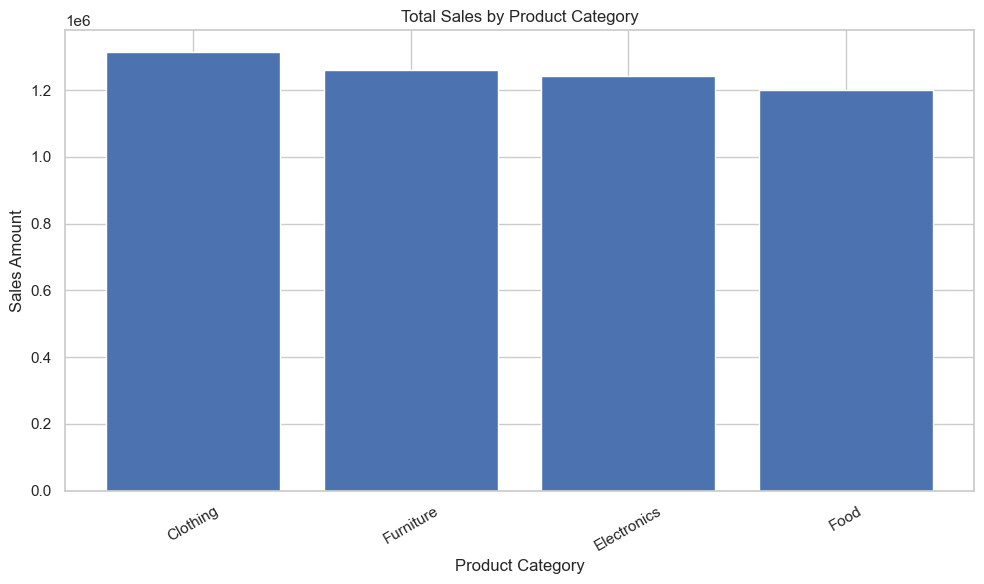

In [111]:
# BAR CHART

plt.figure(figsize=(10, 6))

category_sales = (
    sales_df.groupby("Product_Category")["Sales_Amount"].sum().sort_values(ascending=False))

plt.bar(
    category_sales.index,
    category_sales.values
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Sales Amount")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

**Sales Performance by Sales Representative**

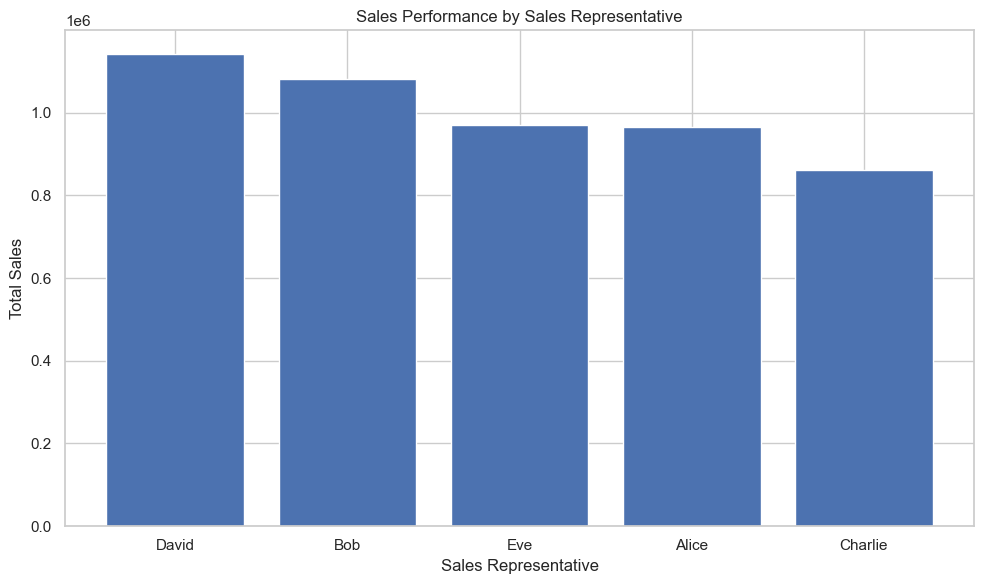

In [112]:
plt.figure(figsize=(10, 6))

rep_sales = (
    sales_df.groupby("Sales_Rep")["Sales_Amount"].sum().sort_values(ascending=False))

plt.bar(rep_sales.index,
        rep_sales.values)

plt.title("Sales Performance by Sales Representative")
plt.xlabel("Sales Representative")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

**Monthly Sales Trend**

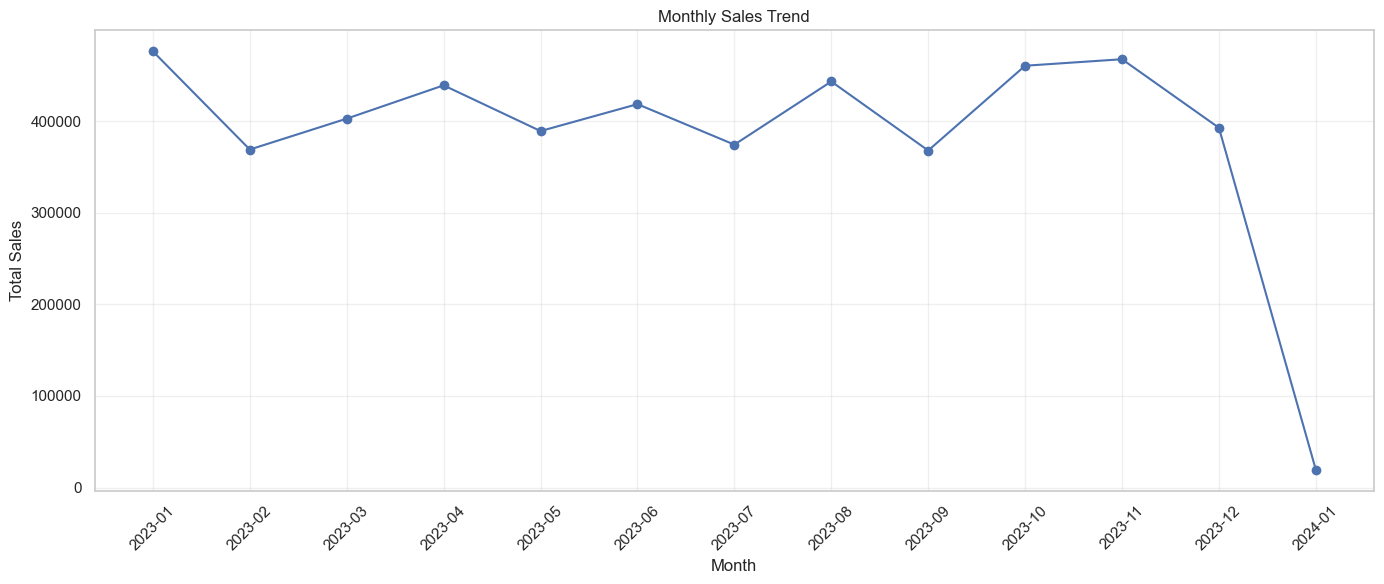

In [113]:
#Line Graph

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Total Sales by Region**

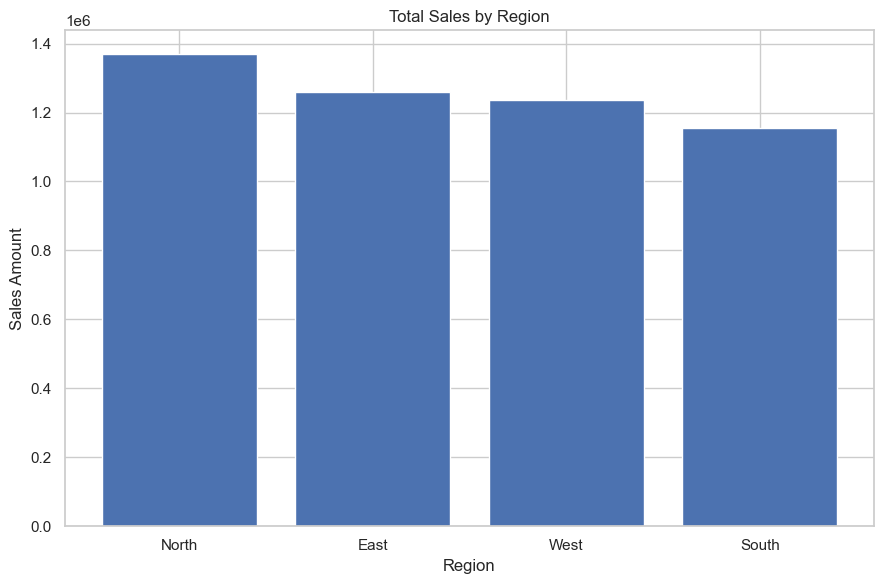

In [114]:
plt.figure(figsize=(9, 6))

region_sales = (
    sales_df.groupby("Region")["Sales_Amount"].sum().sort_values(ascending=False)
)

plt.bar(region_sales.index,region_sales.values)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales Amount")

plt.tight_layout()
plt.show()

**HeatMap**

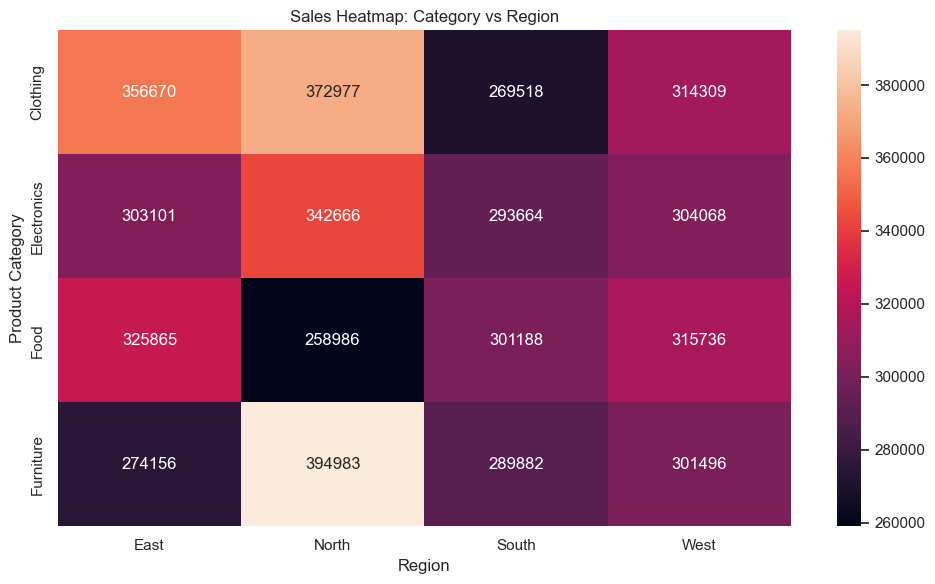

In [115]:
# HEAT MAP

category_region = pd.pivot_table(
    sales_df,
    values="Sales_Amount",
    index="Product_Category",
    columns="Region",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    category_region,
    annot=True,
    fmt=".0f"
)

plt.title("Sales Heatmap: Category vs Region")
plt.xlabel("Region")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [116]:

# SALES CHANNEL ANALYSIS


channel_summary = (sales_df.groupby("Sales_Channel").agg(
        Total_Sales=("Sales_Amount", "sum"),
        Quantity_Sold=("Quantity_Sold", "sum"),
        Average_Sale=("Sales_Amount", "mean")).sort_values("Total_Sales", ascending=False))

display(channel_summary)

,Total_Sales,Quantity_Sold,Average_Sale
Sales_Channel,,,
Retail,2560431.30,12753,5000.842383
Online,2458833.93,12602,5038.594119


**Sales by Sales Channel**

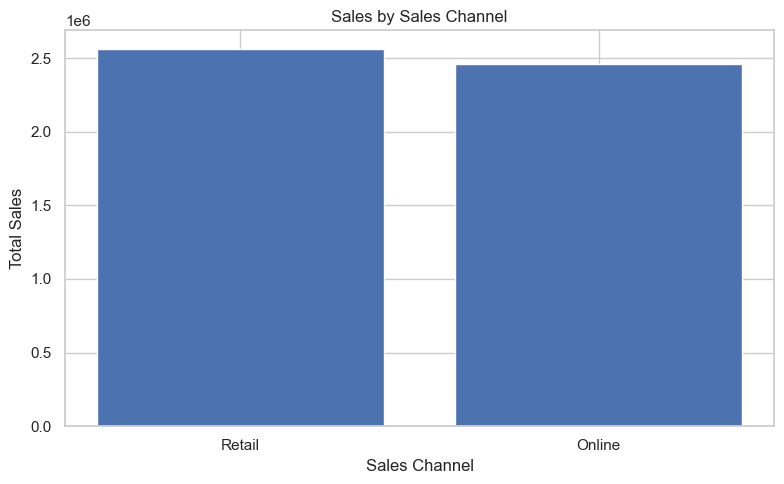

In [117]:
plt.figure(figsize=(8, 5))

plt.bar(
    channel_summary.index,
    channel_summary["Total_Sales"]
)

plt.title("Sales by Sales Channel")
plt.xlabel("Sales Channel")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

In [118]:
payment_summary = (
    sales_df
    .groupby("Payment_Method")
    .agg(
        Total_Sales=("Sales_Amount", "sum"),
        Transactions=("Sales_Amount", "count")
    )
    .sort_values("Total_Sales", ascending=False)
)

display(payment_summary)

,Total_Sales,Transactions
Payment_Method,,
Credit Card,1757563.52,345
Bank Transfer,1717363.17,342
Cash,1544338.54,313


**Correlation Analysis**

In [119]:
# CORRELATION ANALYSIS

correlation_columns = [
    "Sales_Amount",
    "Quantity_Sold",
    "Unit_Cost",
    "Unit_Price",
    "Discount",
    "Total_Cost",
    "Profit"
]

correlation_matrix = sales_df[
    correlation_columns
].corr()

display(correlation_matrix)

,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount,Total_Cost,Profit
Sales_Amount,1.000000,-0.041599,0.009770,0.011812,0.023153,-0.027276,0.078451
Quantity_Sold,-0.041599,1.000000,0.053888,0.057296,-0.007806,0.670130,-0.670445
Unit_Cost,0.009770,0.053888,1.000000,0.995056,-0.017741,0.682131,-0.679781
Unit_Price,0.011812,0.057296,0.995056,1.000000,-0.017027,0.679205,-0.676758
Discount,0.023153,-0.007806,-0.017741,-0.017027,1.000000,-0.013336,0.014487
Total_Cost,-0.027276,0.670130,0.682131,0.679205,-0.013336,1.000000,-0.998687
Profit,0.078451,-0.670445,-0.679781,-0.676758,0.014487,-0.998687,1.000000


**HeatMap**

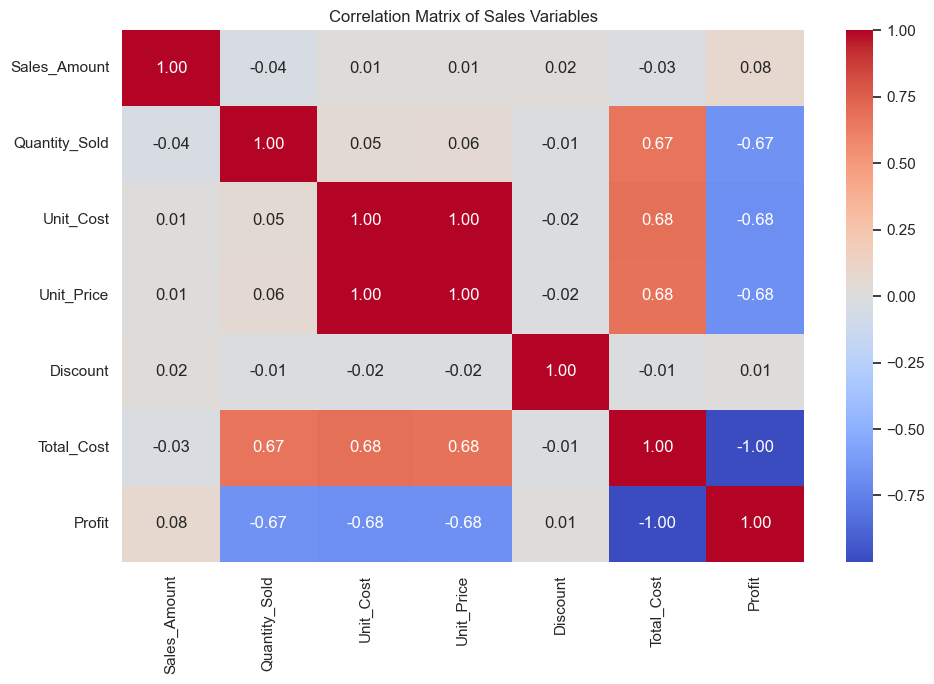

In [120]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Sales Variables")

plt.tight_layout()
plt.show()

**Top 10 Products By Graph** 

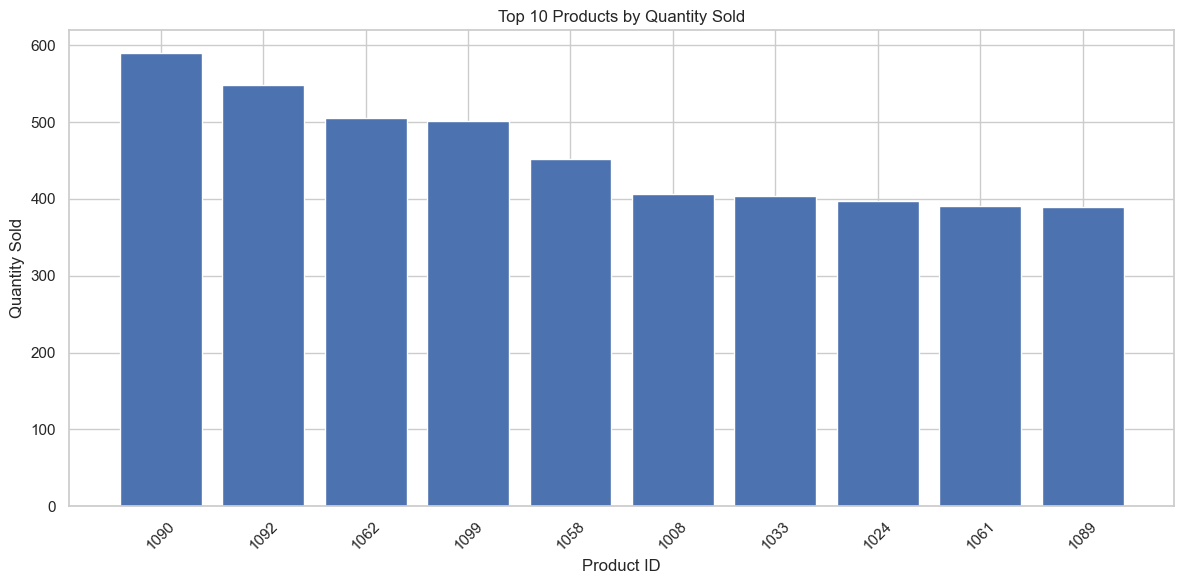

In [121]:
# TOP 10 PRODUCTS


top_products = (sales_df.groupby("Product_ID")["Quantity_Sold"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(12, 6))

plt.bar(
    top_products.index.astype(str),
    top_products.values)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product ID")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**KPI Summary**

In [122]:
# FINAL KPI SUMMARY


final_summary = pd.DataFrame({
    "KPI": [
        "Total Sales",
        "Average Sale",
        "Total Quantity Sold",
        "Total Cost",
        "Total Profit",
        "Average Discount",
        "Average Profit Margin"
    ],
    
    "Value": [
        sales_df["Sales_Amount"].sum(),
        sales_df["Sales_Amount"].mean(),
        sales_df["Quantity_Sold"].sum(),
        sales_df["Total_Cost"].sum(),
        sales_df["Profit"].sum(),
        sales_df["Discount"].mean() * 100,
        sales_df["Profit_Margin"].mean()
    ]
})

display(final_summary)

,KPI,Value
0,Total Sales,5.019265e+06
1,Average Sale,5.019265e+03
2,Total Quantity Sold,2.535500e+04
3,Total Cost,6.384209e+07
4,Total Profit,-5.882283e+07
5,Average Discount,1.523900e+01
6,Average Profit Margin,-3.116804e+03


**Export Clean Data**

In [123]:
# EXPORT CLEAN DATA


output_file = "cleaned_sales_data..xlsx"

sales_df.to_excel(
    output_file,
    index=False
)

print(f"✓ Cleaned dataset saved as: {output_file}")

✓ Cleaned dataset saved as: cleaned_sales_data..xlsx
